In [1]:
#%pip install --upgrade scikit-learn imbalanced-learn

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# Configuration
pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
tcga_df = pd.read_csv('TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('weseq_processed_with_id_and_race_V2.csv')

In [5]:
tcga_df

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,1,1,77.89,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0


In [6]:
cgga_df

,CGGA_ID,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,CGGA_528,0,1,51,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CGGA_579,0,1,42,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,CGGA_653,0,0,33,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,CGGA_715,0,0,43,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,CGGA_723,0,1,25,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,CGGA_P87,1,0,32,2,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1
282,CGGA_P89,1,0,42,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
283,CGGA_P90,1,1,52,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
284,CGGA_P95,0,1,44,2,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [7]:
if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop('CGGA_ID', axis=1)
print('TCGA values\n',tcga_df.count())
print('CGGA values\n',cgga_df.count())

TCGA values
 Grade               839
Gender              839
Age_at_diagnosis    839
Race                839
IDH1                839
TP53                839
ATRX                839
PTEN                839
EGFR                839
CIC                 839
MUC16               839
PIK3CA              839
NF1                 839
PIK3R1              839
FUBP1               839
RB1                 839
NOTCH1              839
BCOR                839
CSMD3               839
SMARCA4             839
GRIN2A              839
IDH2                839
FAT4                839
PDGFRA              839
dtype: int64
CGGA values
 Grade               286
Gender              286
Age_at_diagnosis    286
Race                286
IDH1                286
TP53                286
ATRX                286
PTEN                286
EGFR                286
CIC                 286
MUC16               286
PIK3CA              286
NF1                 286
PIK3R1              286
FUBP1               286
RB1                 286
N

In [8]:
tcgaClassRace = tcga_df.groupby("Race")

In [9]:
print(f'''white {len(tcgaClassRace.get_group(0))}\nblack or african american {len(tcgaClassRace.get_group(1))}\nasian {len(tcgaClassRace.get_group(2))}\namerican indian or alaska native {len(tcgaClassRace.get_group(3))}''')

white 765
black or african american 59
asian 14
american indian or alaska native 1


In [10]:
print('Dropping race to make it less biased on External Dataset')
if 'Race' in cgga_df.columns:
    cgga_df = cgga_df.drop('Race', axis=1)
if 'Race' in tcga_df.columns:
    tcga_df = tcga_df.drop('Race', axis=1)


Dropping race to make it less biased on External Dataset


In [11]:
tcga_df.head(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,33.21,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,1,35.19,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,1,44.65,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,1,33.96,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,87.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
tcga_df.tail(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
829,1,0,58.05,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
830,1,0,61.31,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
831,1,0,66.30,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
832,1,0,64.12,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
833,1,0,56.31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
834,1,1,77.89,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0
838,1,0,76.61,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
cgga_df.head(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,1,51,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,33,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,43,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,25,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,45,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,0,1,40,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,43,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
9,0,0,31,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
cgga_df.tail(10)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
276,1,1,46,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
277,0,1,40,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
278,0,1,28,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
279,0,1,40,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
280,0,1,34,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
281,1,0,32,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1
282,1,0,42,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
283,1,1,52,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
284,0,1,44,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
285,1,0,52,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [15]:
tcgaClassGrade = tcga_df.groupby("Grade")
print('Glioma grade class information (0 = "LGG"; 1 = "GBM")')
gradeCount = tcga_df['Grade'].value_counts()
print(gradeCount)
print(f"Difference {len(tcgaClassGrade.get_group(0))-len(tcgaClassGrade.get_group(1))}")
print(tcga_df.nunique())

Glioma grade class information (0 = "LGG"; 1 = "GBM")
Grade
0    487
1    352
Name: count, dtype: int64
Difference 135
Grade                 2
Gender                2
Age_at_diagnosis    766
IDH1                  2
TP53                  2
ATRX                  2
PTEN                  2
EGFR                  2
CIC                   2
MUC16                 2
PIK3CA                2
NF1                   2
PIK3R1                2
FUBP1                 2
RB1                   2
NOTCH1                2
BCOR                  2
CSMD3                 2
SMARCA4               2
GRIN2A                2
IDH2                  2
FAT4                  2
PDGFRA                2
dtype: int64


In [16]:
print('LGG (WHO II/III) -> 0, GBM (WHO IV) -> 1 were converted when merged the clinical data and mutation.\nAlso Gender: Male -> 0, Female -> 1, Set to 2 (Asian) to match TCGA encoding for CGGA data(Dropped),\nNaN are classified as Wildtype -> 0, missense_variants,stop_gained as Mutant -> 1')

cggaClassGrade = cgga_df.groupby("Grade")
gradeCount = cgga_df['Grade'].value_counts()
print(gradeCount)
print(f"Difference {len(cggaClassGrade.get_group(0))-len(cggaClassGrade.get_group(1))}")
print(cgga_df.nunique())

LGG (WHO II/III) -> 0, GBM (WHO IV) -> 1 were converted when merged the clinical data and mutation.
Also Gender: Male -> 0, Female -> 1, Set to 2 (Asian) to match TCGA encoding for CGGA data(Dropped),
NaN are classified as Wildtype -> 0, missense_variants,stop_gained as Mutant -> 1
Grade
0    184
1    102
Name: count, dtype: int64
Difference 82
Grade                2
Gender               2
Age_at_diagnosis    56
IDH1                 2
TP53                 2
ATRX                 2
PTEN                 2
EGFR                 2
CIC                  2
MUC16                2
PIK3CA               2
NF1                  2
PIK3R1               2
FUBP1                2
RB1                  2
NOTCH1               2
BCOR                 2
CSMD3                2
SMARCA4              2
GRIN2A               2
IDH2                 2
FAT4                 2
PDGFRA               2
dtype: int64


In [17]:
maxage=tcga_df.Age_at_diagnosis.max()
minage=tcga_df.Age_at_diagnosis.min()
avgage = tcga_df.Age_at_diagnosis.mean()
print(f"TCGA min age {minage}, max age {maxage}, avg age {avgage}")

TCGA min age 14.42, max age 89.29, avg age 50.93541120381406


In [18]:
maxC_age=cgga_df.Age_at_diagnosis.max()
minC_age=cgga_df.Age_at_diagnosis.min()
avgC_age = cgga_df.Age_at_diagnosis.mean()
print(f"CGGA min age {minC_age}, max age {maxC_age}, avg age {avgC_age}")

CGGA min age 10, max age 76, avg age 41.96853146853147


In [19]:
common_cols = list(set(tcga_df.columns) & set(cgga_df.columns))

tcga_df1 = tcga_df[common_cols]
cgga_df1 = cgga_df[common_cols]

print(f"Original TCGA Count: {len(tcga_df1)} (Min Age: {tcga_df1['Age_at_diagnosis'].min()})")
print(f"Original CGGA Count: {len(cgga_df1)} (Min Age: {cgga_df1['Age_at_diagnosis'].min()})")

Original TCGA Count: 839 (Min Age: 14.42)
Original CGGA Count: 286 (Min Age: 10)


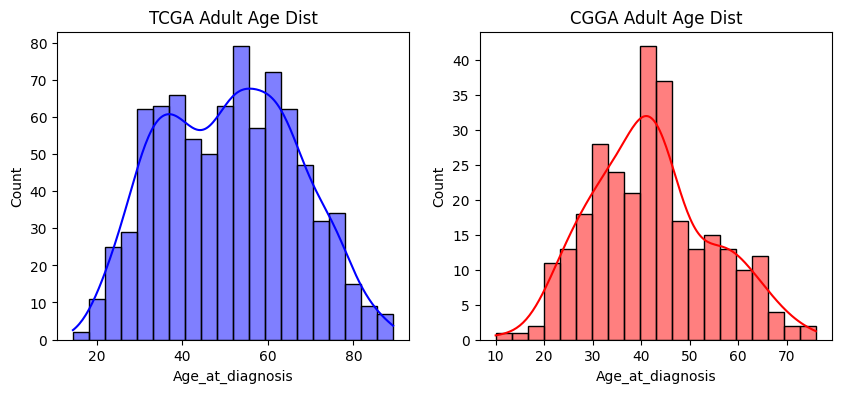

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(tcga_df['Age_at_diagnosis'], bins=20, color='blue', kde=True)
plt.title('TCGA Adult Age Dist')
plt.subplot(1, 2, 2)
sns.histplot(cgga_df['Age_at_diagnosis'], bins=20, color='red', kde=True)
plt.title('CGGA Adult Age Dist')
plt.show()

In [21]:
print("Z normalization")
print('TCGA')
mean_age = tcga_df['Age_at_diagnosis'].mean()
std_age = tcga_df['Age_at_diagnosis'].std()
z_scores = (tcga_df['Age_at_diagnosis'] - mean_age) / std_age
print(f'mean age: {mean_age} std age {std_age} \nZ score \n{z_scores}' )

print('CGGA')
Cmean_age = cgga_df['Age_at_diagnosis'].mean()
Cstd_age = cgga_df['Age_at_diagnosis'].std()
Cz_scores = (cgga_df['Age_at_diagnosis'] - Cmean_age) / Cstd_age
print(f'mean age: {Cmean_age} std age {Cstd_age} \nZ score \n{Cz_scores}' )

Z normalization
TCGA
mean age: 50.93541120381406 std age 15.70233865321824 
Z score 
0      0.023219
1     -0.777936
2     -1.004017
3     -1.156223
4     -1.237103
         ...   
834    1.716597
835    2.180859
836    1.691123
837    0.789347
838    1.635081
Name: Age_at_diagnosis, Length: 839, dtype: float64
CGGA
mean age: 41.96853146853147 std age 12.339171228562243 
Z score 
0      0.731935
1      0.002550
2     -0.726834
3      0.083593
4     -1.375176
         ...   
281   -0.807877
282    0.002550
283    0.812977
284    0.164636
285    0.812977
Name: Age_at_diagnosis, Length: 286, dtype: float64


In [22]:
print('TCGA')
outliers = tcga_df[np.abs(z_scores) > 3]

print(f"Mean Age: {mean_age:.2f}")
if len(outliers) == 0:
    print("RESULT: No statistical outliers detected.")
else:
    print(f"RESULT: {len(outliers)} statistical outliers detected (Age > 3 SDs from mean).")

print('CGGA')
C_outliers = cgga_df[np.abs(Cz_scores) > 3]

print(f"Mean Age: {Cmean_age:.2f}")
if len(C_outliers) == 0:
    print("RESULT: No statistical outliers detected.")
else:
    print(f"RESULT: {len(C_outliers)} statistical outliers detected (Age > 3 SDs from mean).")

TCGA
Mean Age: 50.94
RESULT: No statistical outliers detected.
CGGA
Mean Age: 41.97
RESULT: No statistical outliers detected.


In [23]:
scaler = MinMaxScaler()
scaler.fit(tcga_df[['Age_at_diagnosis']])
#transform TCGA
tcga_df['Age_at_diagnosis'] = scaler.transform(tcga_df[['Age_at_diagnosis']])
#transform CGGA
cgga_df['Age_at_diagnosis'] = scaler.transform(cgga_df[['Age_at_diagnosis']])

In [24]:
tcga_df.head(3)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,0.492587,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,0.324563,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0.277147,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [25]:
cgga_df.head(3)

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,1,0.488580,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0.368372,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0.248163,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
#import models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [27]:
# Data Preparation
X_tcga = tcga_df.drop('Grade', axis=1)
y_tcga = tcga_df['Grade']

X_cgga = cgga_df.drop('Grade', axis=1)
y_cgga = cgga_df['Grade']

In [28]:
# Split TCGA into 60% training, 20% validation, 20% test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X_tcga, y_tcga, test_size=0.2, random_state=42, stratify=y_tcga
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.25, random_state=42, stratify=y_train_temp
)  # 0.25 of 80% = 20% of original

In [29]:
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X_tcga)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X_tcga)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X_tcga)*100:.1f}%)")
print(f"External validation (CGGA) size: {len(X_cgga)}")

Training set size: 503 (60.0%)
Validation set size: 168 (20.0%)
Test set size: 168 (20.0%)
External validation (CGGA) size: 286


In [30]:
#Normalization
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_cgga_scaled = scaler.transform(X_cgga)

In [31]:
print(f"Class distribution in original training: {Counter(y_train)}")


Class distribution in original training: Counter({0: 292, 1: 211})


In [32]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Training size: {len(X_train_balanced)}")
print(f"Class distribution after SMOTE: {Counter(y_train_balanced)}")

After SMOTE - Training size: 584
Class distribution after SMOTE: Counter({1: 292, 0: 292})


In [33]:
class ModelTrainer:
    def __init__(self, model, model_name):
        self.model = model
        self.model_name = model_name
        self.results = {}
        
    def train_with_cv(self, X, y, n_splits=10):
        """Train model with cross-validation"""
        print(f"\n{'='*60}")
        print(f"Training {self.model_name} with {n_splits}-fold CV")
        print('='*60)
        
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_fold_train, X_fold_val = X[train_idx], X[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Train on this fold
            self.model.fit(X_fold_train, y_fold_train)
            
            # Predict and evaluate
            y_pred = self.model.predict(X_fold_val)
            
            # Calculate metrics
            accuracy = accuracy_score(y_fold_val, y_pred)
            precision = precision_score(y_fold_val, y_pred, average='weighted')
            recall = recall_score(y_fold_val, y_pred, average='weighted')
            f1 = f1_score(y_fold_val, y_pred, average='weighted')
            
            cv_scores.append({
                'fold': fold + 1,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1
            })
            
            print(f"  Fold {fold + 1}: Accuracy = {accuracy:.4f}, F1 = {f1:.4f}")
        
        # Calculate average CV scores
        avg_scores = {
            'accuracy': np.mean([s['accuracy'] for s in cv_scores]),
            'precision': np.mean([s['precision'] for s in cv_scores]),
            'recall': np.mean([s['recall'] for s in cv_scores]),
            'f1': np.mean([s['f1'] for s in cv_scores])
        }
        
        self.results['cv_scores'] = cv_scores
        self.results['cv_avg'] = avg_scores
        
        print(f"\nCV Averages: Accuracy = {avg_scores['accuracy']:.4f}, "
              f"Precision = {avg_scores['precision']:.4f}, "
              f"Recall = {avg_scores['recall']:.4f}, "
              f"F1 = {avg_scores['f1']:.4f}")
        
        return avg_scores
    
    def train_final(self, X_train, y_train):
        """Train final model on entire training set"""
        print(f"\nTraining final {self.model_name} model...")
        self.model.fit(X_train, y_train)
        print("Training completed!")
    
    def evaluate(self, X_sets, y_sets, set_names):
        """Evaluate model on multiple datasets"""
        print(f"\nEvaluating {self.model_name}...")
        
        evaluation_results = {}
        
        for i, (X, y) in enumerate(zip(X_sets, y_sets)):
            set_name = set_names[i]
            y_pred = self.model.predict(X)
            
            # Calculate metrics
            accuracy = accuracy_score(y, y_pred)
            precision = precision_score(y, y_pred, average='weighted')
            recall = recall_score(y, y_pred, average='weighted')
            f1 = f1_score(y, y_pred, average='weighted')
            
            # Try to calculate ROC AUC
            try:
                y_pred_proba = self.model.predict_proba(X)
                if len(np.unique(y)) > 1:
                    roc_auc = roc_auc_score(y, y_pred_proba[:, 1])
                else:
                    roc_auc = None
            except:
                roc_auc = None
            
            # Confusion matrix
            cm = confusion_matrix(y, y_pred)
            
            evaluation_results[set_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'roc_auc': roc_auc,
                'confusion_matrix': cm
            }
            
            print(f"\n  {set_name} Set:")
            print(f"    Accuracy:  {accuracy:.4f}")
            print(f"    Precision: {precision:.4f}")
            print(f"    Recall:    {recall:.4f}")
            print(f"    F1-Score:  {f1:.4f}")
            if roc_auc:
                print(f"    ROC-AUC:   {roc_auc:.4f}")
        
        self.results['evaluation'] = evaluation_results
        return evaluation_results
    
    def plot_confusion_matrices(self):
        """Plot confusion matrices for all evaluated sets"""
        if 'evaluation' not in self.results:
            print("No evaluation results to plot!")
            return
        
        evaluation = self.results['evaluation']
        n_sets = len(evaluation)
        
        fig, axes = plt.subplots(1, n_sets, figsize=(5*n_sets, 4))
        if n_sets == 1:
            axes = [axes]
        
        for idx, (set_name, results) in enumerate(evaluation.items()):
            cm = results['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
            axes[idx].set_title(f'{self.model_name}\n{set_name} Set')
            axes[idx].set_xlabel('Predicted')
            axes[idx].set_ylabel('Actual')
        
        plt.tight_layout()
        plt.show()
    
    def get_feature_importance(self, feature_names):
        """Get feature importance if the model supports it"""
        if hasattr(self.model, 'feature_importances_'):
            importances = self.model.feature_importances_
            indices = np.argsort(importances)[::-1]
            
            # Create DataFrame
            importance_df = pd.DataFrame({
                'feature': feature_names[indices],
                'importance': importances[indices]
            })
            
            # Plot top features
            plt.figure(figsize=(10, 6))
            top_n = min(15, len(feature_names))
            plt.barh(range(top_n), importance_df['importance'].values[:top_n][::-1])
            plt.yticks(range(top_n), importance_df['feature'].values[:top_n][::-1])
            plt.xlabel('Importance')
            plt.title(f'{self.model_name} - Top {top_n} Feature Importance')
            plt.tight_layout()
            plt.show()
            
            return importance_df
        else:
            print(f"{self.model_name} doesn't support feature importance analysis.")
            return None

In [34]:
# Define all models
models_dict = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42,
        class_weight='balanced'
    ),
    'LogisticRegression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss',
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=50,
        random_state=42
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ),
    'CatBoost': CatBoostClassifier(
        random_state=42, 
        verbose=0,
        auto_class_weights='Balanced'
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, 
        verbose=-1,
        class_weight='balanced'
    ),
    'RidgeClassifier': RidgeClassifier(
        random_state=42,
        class_weight='balanced'
    )
}

In [35]:
# Create trainer objects for each model
trainers = {}
for name, model in models_dict.items():
    trainers[name] = ModelTrainer(model, name)


1. RANDOM FOREST CLASSIFIER

Training RandomForest with 10-fold CV
  Fold 1: Accuracy = 0.8475, F1 = 0.8461
  Fold 2: Accuracy = 0.8475, F1 = 0.8475
  Fold 3: Accuracy = 0.7627, F1 = 0.7626
  Fold 4: Accuracy = 0.8814, F1 = 0.8814
  Fold 5: Accuracy = 0.8793, F1 = 0.8793
  Fold 6: Accuracy = 0.8103, F1 = 0.8103
  Fold 7: Accuracy = 0.8103, F1 = 0.8075
  Fold 8: Accuracy = 0.9138, F1 = 0.9138
  Fold 9: Accuracy = 0.8448, F1 = 0.8444
  Fold 10: Accuracy = 0.8793, F1 = 0.8790

CV Averages: Accuracy = 0.8477, Precision = 0.8518, Recall = 0.8477, F1 = 0.8472

Training final RandomForest model...
Training completed!

Evaluating RandomForest...

  Validation Set:
    Accuracy:  0.8571
    Precision: 0.8648
    Recall:    0.8571
    F1-Score:  0.8580
    ROC-AUC:   0.9016

  Test Set:
    Accuracy:  0.8214
    Precision: 0.8236
    Recall:    0.8214
    F1-Score:  0.8220
    ROC-AUC:   0.9029

  External (CGGA) Set:
    Accuracy:  0.6993
    Precision: 0.7100
    Recall:    0.6993
    F1-Scor

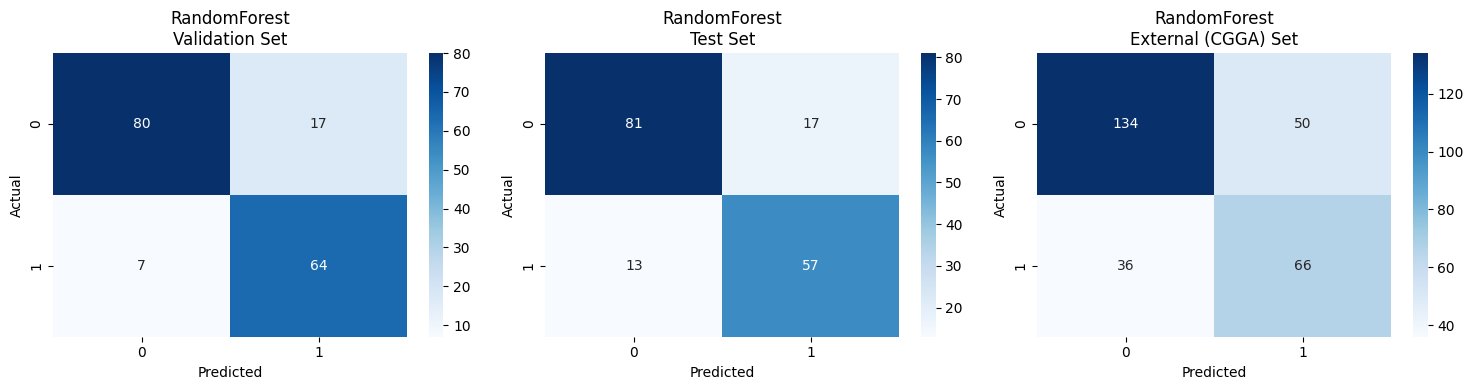

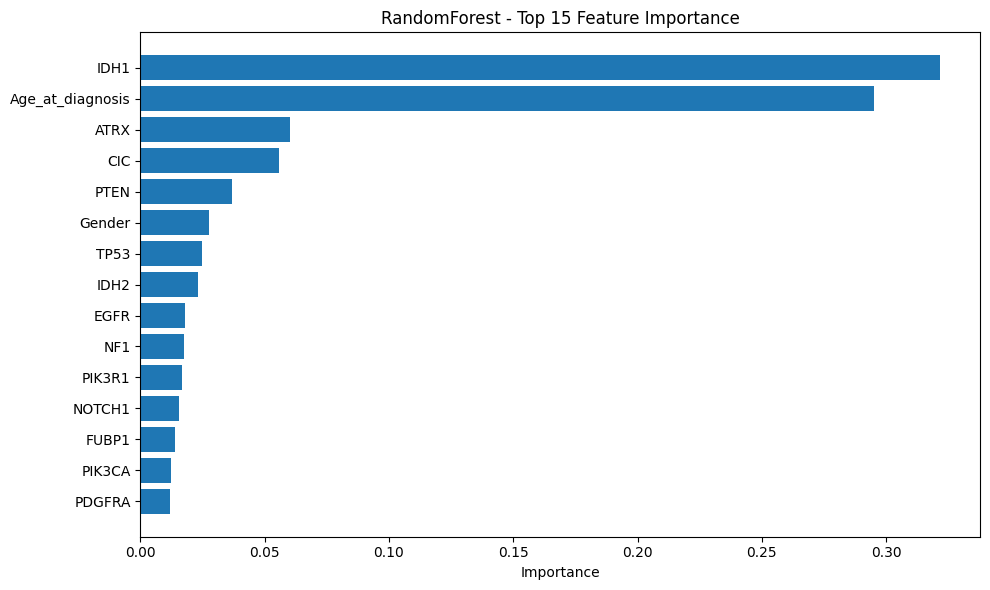

In [36]:
#RandomForest
print("\n" + "="*60)
print("1. RANDOM FOREST CLASSIFIER")
print("="*60)

rf_trainer = trainers['RandomForest']

# Cross-validation
rf_cv_results = rf_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
rf_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
rf_eval_results = rf_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
rf_trainer.plot_confusion_matrices()

# Feature importance
feature_names = X_tcga.columns
rf_importance = rf_trainer.get_feature_importance(feature_names)


2. XGBOOST CLASSIFIER

Training XGBoost with 10-fold CV
  Fold 1: Accuracy = 0.8136, F1 = 0.8129
  Fold 2: Accuracy = 0.8475, F1 = 0.8475
  Fold 3: Accuracy = 0.8136, F1 = 0.8132
  Fold 4: Accuracy = 0.8814, F1 = 0.8814
  Fold 5: Accuracy = 0.8966, F1 = 0.8964
  Fold 6: Accuracy = 0.8103, F1 = 0.8098
  Fold 7: Accuracy = 0.8448, F1 = 0.8425
  Fold 8: Accuracy = 0.8966, F1 = 0.8966
  Fold 9: Accuracy = 0.8276, F1 = 0.8268
  Fold 10: Accuracy = 0.8621, F1 = 0.8621

CV Averages: Accuracy = 0.8494, Precision = 0.8534, Recall = 0.8494, F1 = 0.8489

Training final XGBoost model...
Training completed!

Evaluating XGBoost...

  Validation Set:
    Accuracy:  0.8512
    Precision: 0.8538
    Recall:    0.8512
    F1-Score:  0.8518
    ROC-AUC:   0.9001

  Test Set:
    Accuracy:  0.8036
    Precision: 0.8066
    Recall:    0.8036
    F1-Score:  0.8044
    ROC-AUC:   0.8962

  External (CGGA) Set:
    Accuracy:  0.6713
    Precision: 0.6944
    Recall:    0.6713
    F1-Score:  0.6774
    ROC-AU

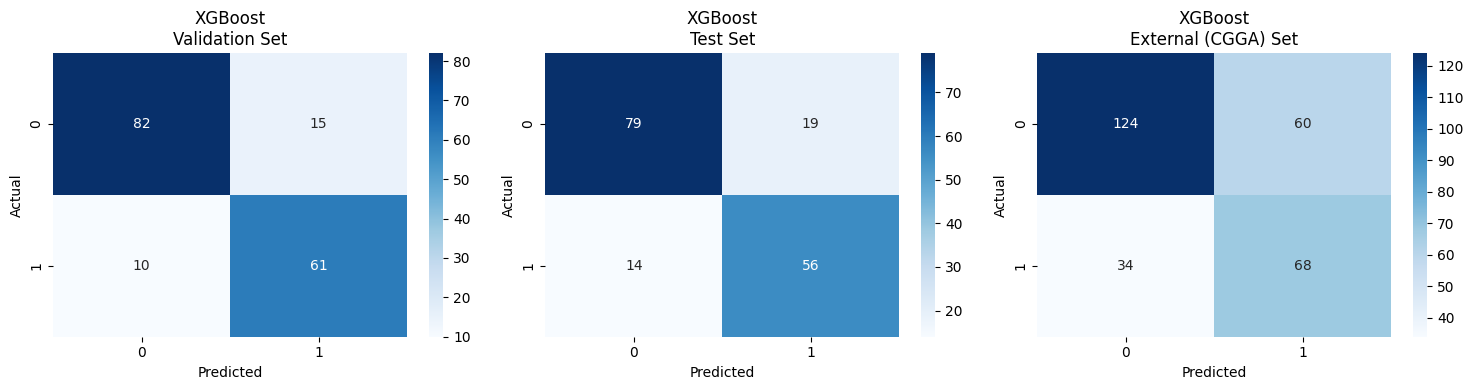

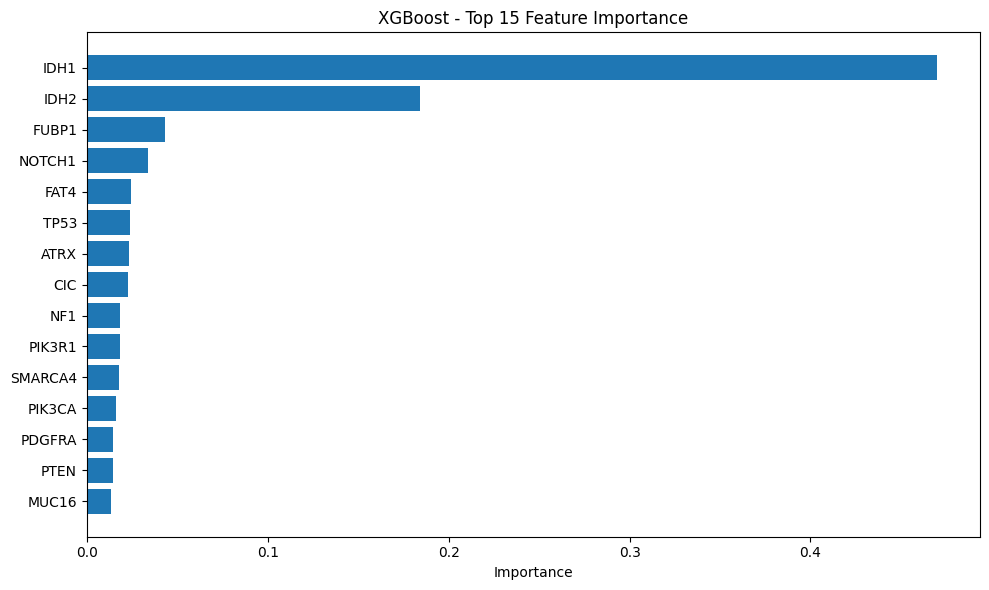

In [37]:
print("\n" + "="*60)
print("2. XGBOOST CLASSIFIER")
print("="*60)

xgb_trainer = trainers['XGBoost']

# Cross-validation
xgb_cv_results = xgb_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
xgb_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
xgb_eval_results = xgb_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
xgb_trainer.plot_confusion_matrices()

# Feature importance
xgb_importance = xgb_trainer.get_feature_importance(feature_names)



3. LOGISTIC REGRESSION

Training LogisticRegression with 10-fold CV
  Fold 1: Accuracy = 0.8644, F1 = 0.8627
  Fold 2: Accuracy = 0.8983, F1 = 0.8981
  Fold 3: Accuracy = 0.8136, F1 = 0.8132
  Fold 4: Accuracy = 0.9492, F1 = 0.9492
  Fold 5: Accuracy = 0.9138, F1 = 0.9138
  Fold 6: Accuracy = 0.8276, F1 = 0.8276
  Fold 7: Accuracy = 0.8448, F1 = 0.8425
  Fold 8: Accuracy = 0.9138, F1 = 0.9138
  Fold 9: Accuracy = 0.8448, F1 = 0.8448
  Fold 10: Accuracy = 0.8966, F1 = 0.8961

CV Averages: Accuracy = 0.8767, Precision = 0.8818, Recall = 0.8767, F1 = 0.8762

Training final LogisticRegression model...
Training completed!

Evaluating LogisticRegression...

  Validation Set:
    Accuracy:  0.8869
    Precision: 0.8958
    Recall:    0.8869
    F1-Score:  0.8876
    ROC-AUC:   0.9228

  Test Set:
    Accuracy:  0.8750
    Precision: 0.8872
    Recall:    0.8750
    F1-Score:  0.8759
    ROC-AUC:   0.9127

  External (CGGA) Set:
    Accuracy:  0.6888
    Precision: 0.7246
    Recall:    0.688

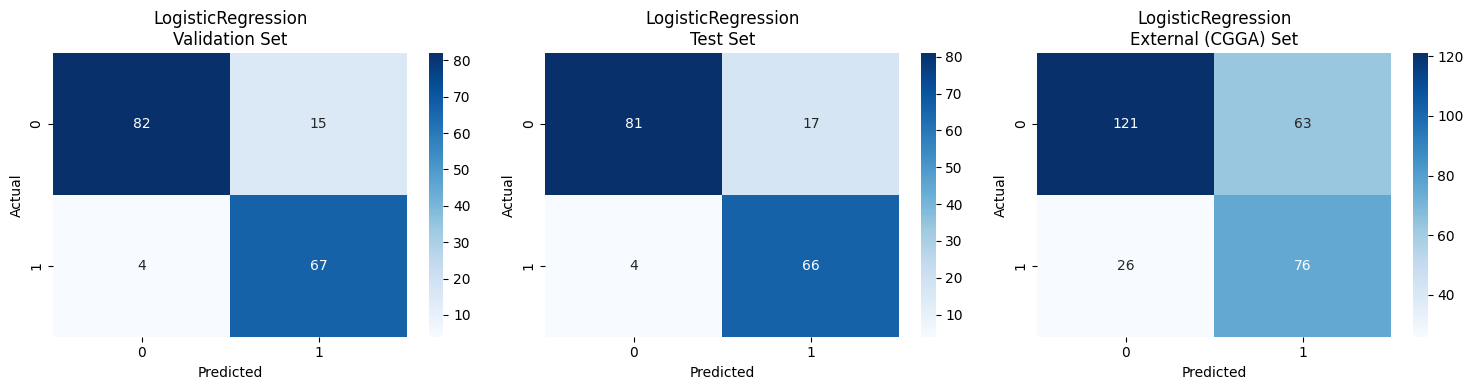

In [38]:

print("\n" + "="*60)
print("3. LOGISTIC REGRESSION")
print("="*60)

lr_trainer = trainers['LogisticRegression']

# Cross-validation
lr_cv_results = lr_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
lr_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
lr_eval_results = lr_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
lr_trainer.plot_confusion_matrices()


4. ADABOOST CLASSIFIER

Training AdaBoost with 10-fold CV
  Fold 1: Accuracy = 0.8644, F1 = 0.8627
  Fold 2: Accuracy = 0.8983, F1 = 0.8981
  Fold 3: Accuracy = 0.8136, F1 = 0.8132
  Fold 4: Accuracy = 0.9153, F1 = 0.9153
  Fold 5: Accuracy = 0.8966, F1 = 0.8964
  Fold 6: Accuracy = 0.8276, F1 = 0.8276
  Fold 7: Accuracy = 0.8276, F1 = 0.8242
  Fold 8: Accuracy = 0.9138, F1 = 0.9138
  Fold 9: Accuracy = 0.8276, F1 = 0.8274
  Fold 10: Accuracy = 0.8966, F1 = 0.8961

CV Averages: Accuracy = 0.8681, Precision = 0.8741, Recall = 0.8681, F1 = 0.8675

Training final AdaBoost model...
Training completed!

Evaluating AdaBoost...

  Validation Set:
    Accuracy:  0.8750
    Precision: 0.8870
    Recall:    0.8750
    F1-Score:  0.8758
    ROC-AUC:   0.9336

  Test Set:
    Accuracy:  0.8690
    Precision: 0.8829
    Recall:    0.8690
    F1-Score:  0.8700
    ROC-AUC:   0.9187

  External (CGGA) Set:
    Accuracy:  0.6853
    Precision: 0.7251
    Recall:    0.6853
    F1-Score:  0.6919
    RO

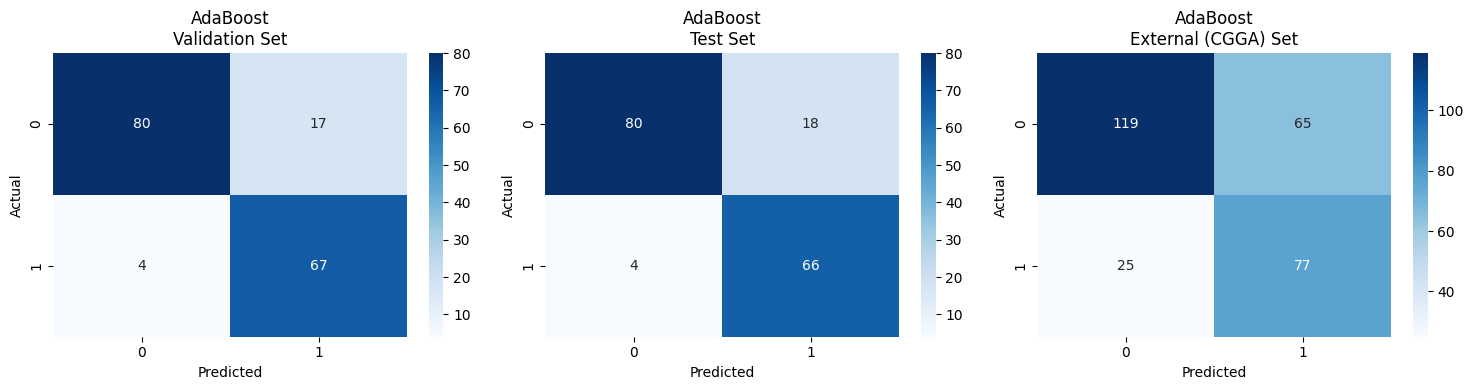

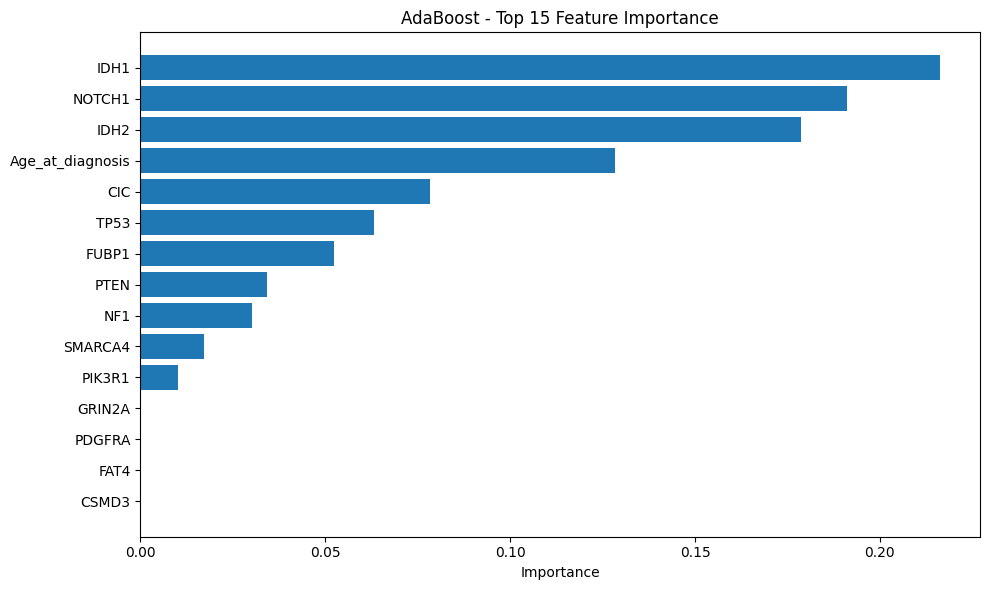

In [39]:
print("\n" + "="*60)
print("4. ADABOOST CLASSIFIER")
print("="*60)

ada_trainer = trainers['AdaBoost']

# Cross-validation
ada_cv_results = ada_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
ada_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
ada_eval_results = ada_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
ada_trainer.plot_confusion_matrices()

# Feature importance
ada_importance = ada_trainer.get_feature_importance(feature_names)



5. EXTRATREES CLASSIFIER

Training ExtraTrees with 10-fold CV
  Fold 1: Accuracy = 0.7966, F1 = 0.7954
  Fold 2: Accuracy = 0.8644, F1 = 0.8644
  Fold 3: Accuracy = 0.7797, F1 = 0.7793
  Fold 4: Accuracy = 0.8814, F1 = 0.8814
  Fold 5: Accuracy = 0.8793, F1 = 0.8793
  Fold 6: Accuracy = 0.7931, F1 = 0.7929
  Fold 7: Accuracy = 0.8103, F1 = 0.8098
  Fold 8: Accuracy = 0.8793, F1 = 0.8793
  Fold 9: Accuracy = 0.8276, F1 = 0.8268
  Fold 10: Accuracy = 0.8448, F1 = 0.8448

CV Averages: Accuracy = 0.8357, Precision = 0.8378, Recall = 0.8357, F1 = 0.8353

Training final ExtraTrees model...
Training completed!

Evaluating ExtraTrees...

  Validation Set:
    Accuracy:  0.8274
    Precision: 0.8302
    Recall:    0.8274
    F1-Score:  0.8280
    ROC-AUC:   0.8737

  Test Set:
    Accuracy:  0.7917
    Precision: 0.7921
    Recall:    0.7917
    F1-Score:  0.7919
    ROC-AUC:   0.8724

  External (CGGA) Set:
    Accuracy:  0.6923
    Precision: 0.6982
    Recall:    0.6923
    F1-Score:  0.694

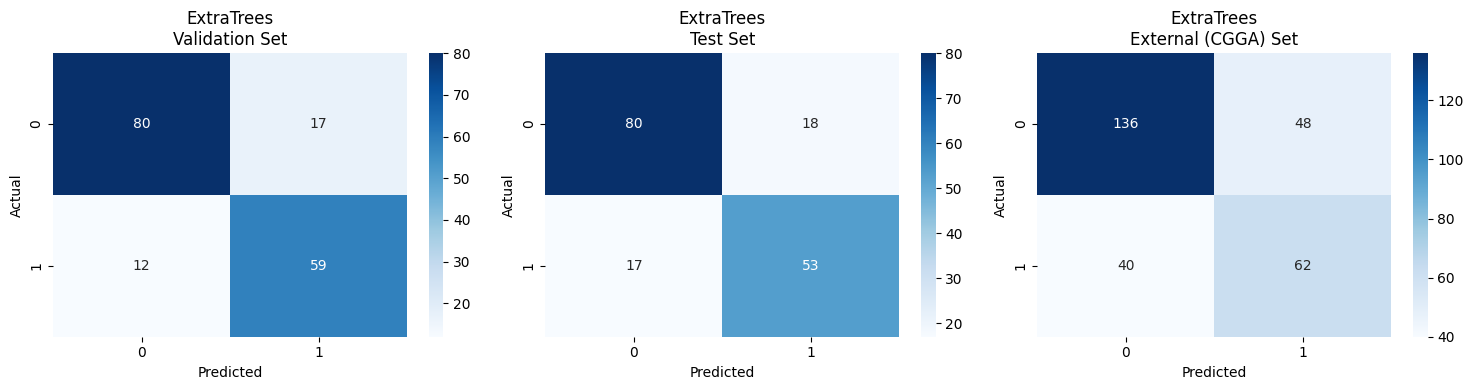

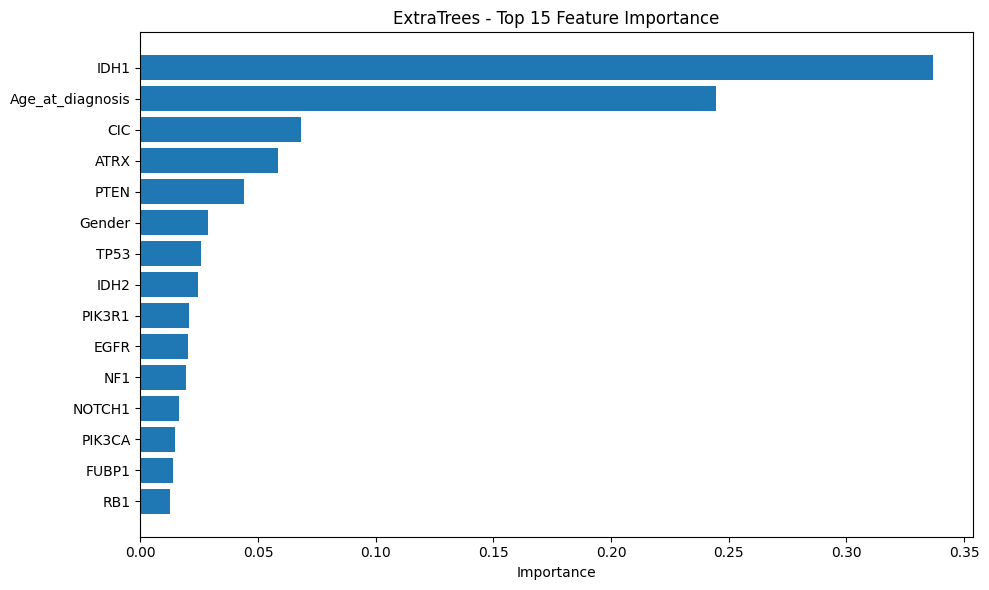

In [40]:
print("\n" + "="*60)
print("5. EXTRATREES CLASSIFIER")
print("="*60)

et_trainer = trainers['ExtraTrees']

# Cross-validation
et_cv_results = et_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
et_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
et_eval_results = et_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
et_trainer.plot_confusion_matrices()

# Feature importance
et_importance = et_trainer.get_feature_importance(feature_names)




6. CATBOOST CLASSIFIER

Training CatBoost with 10-fold CV
  Fold 1: Accuracy = 0.8814, F1 = 0.8803
  Fold 2: Accuracy = 0.8983, F1 = 0.8983
  Fold 3: Accuracy = 0.8136, F1 = 0.8132
  Fold 4: Accuracy = 0.9153, F1 = 0.9153
  Fold 5: Accuracy = 0.8966, F1 = 0.8964
  Fold 6: Accuracy = 0.8103, F1 = 0.8103
  Fold 7: Accuracy = 0.8448, F1 = 0.8425
  Fold 8: Accuracy = 0.9138, F1 = 0.9138
  Fold 9: Accuracy = 0.8448, F1 = 0.8448
  Fold 10: Accuracy = 0.9138, F1 = 0.9136

CV Averages: Accuracy = 0.8733, Precision = 0.8777, Recall = 0.8733, F1 = 0.8728

Training final CatBoost model...
Training completed!

Evaluating CatBoost...

  Validation Set:
    Accuracy:  0.8929
    Precision: 0.9004
    Recall:    0.8929
    F1-Score:  0.8935
    ROC-AUC:   0.9334

  Test Set:
    Accuracy:  0.8333
    Precision: 0.8390
    Recall:    0.8333
    F1-Score:  0.8343
    ROC-AUC:   0.9207

  External (CGGA) Set:
    Accuracy:  0.7098
    Precision: 0.7332
    Recall:    0.7098
    F1-Score:  0.7153
    RO

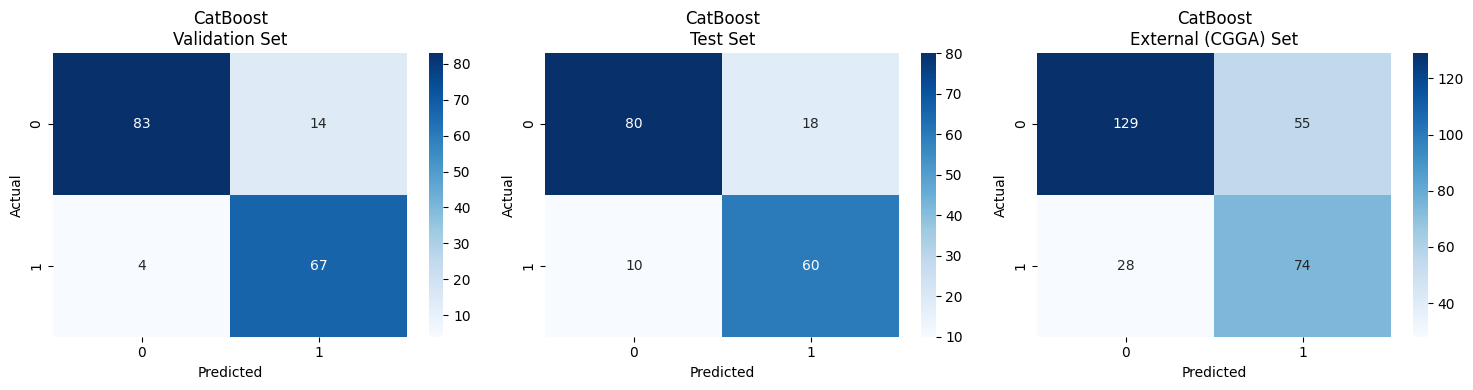

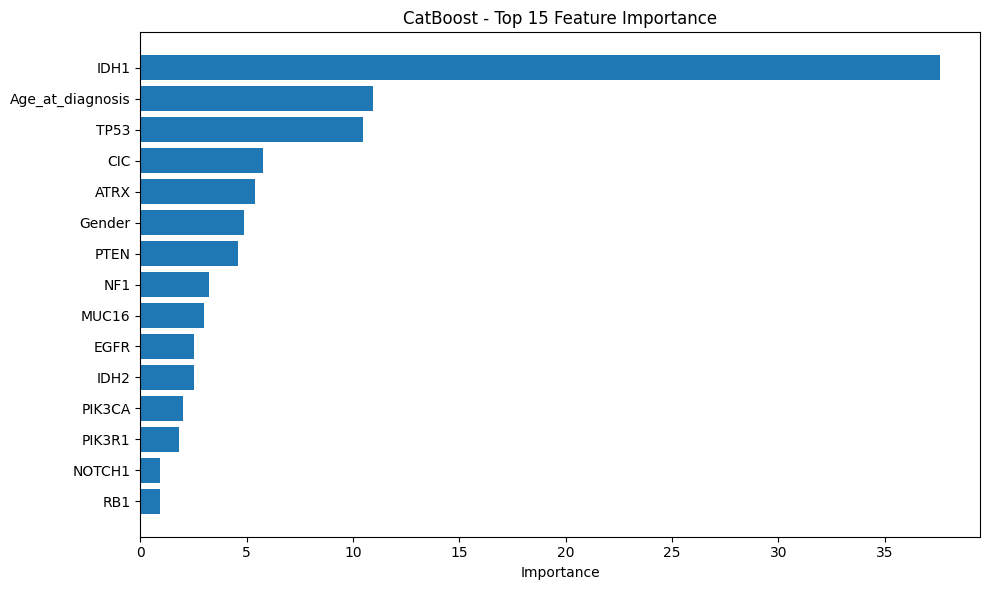

In [41]:
print("\n" + "="*60)
print("6. CATBOOST CLASSIFIER")
print("="*60)

cat_trainer = trainers['CatBoost']

# Cross-validation
cat_cv_results = cat_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
cat_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
cat_eval_results = cat_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
cat_trainer.plot_confusion_matrices()

# Feature importance
cat_importance = cat_trainer.get_feature_importance(feature_names)



7. LIGHTGBM CLASSIFIER

Training LightGBM with 10-fold CV
  Fold 1: Accuracy = 0.8305, F1 = 0.8295
  Fold 2: Accuracy = 0.8475, F1 = 0.8475
  Fold 3: Accuracy = 0.8136, F1 = 0.8132
  Fold 4: Accuracy = 0.8814, F1 = 0.8814
  Fold 5: Accuracy = 0.9138, F1 = 0.9138
  Fold 6: Accuracy = 0.8103, F1 = 0.8089
  Fold 7: Accuracy = 0.8276, F1 = 0.8242
  Fold 8: Accuracy = 0.8621, F1 = 0.8621
  Fold 9: Accuracy = 0.8276, F1 = 0.8268
  Fold 10: Accuracy = 0.8448, F1 = 0.8444

CV Averages: Accuracy = 0.8459, Precision = 0.8517, Recall = 0.8459, F1 = 0.8452

Training final LightGBM model...
Training completed!

Evaluating LightGBM...

  Validation Set:
    Accuracy:  0.8631
    Precision: 0.8674
    Recall:    0.8631
    F1-Score:  0.8637
    ROC-AUC:   0.9089

  Test Set:
    Accuracy:  0.8214
    Precision: 0.8236
    Recall:    0.8214
    F1-Score:  0.8220
    ROC-AUC:   0.8940

  External (CGGA) Set:
    Accuracy:  0.6993
    Precision: 0.6993
    Recall:    0.6993
    F1-Score:  0.6993
    RO

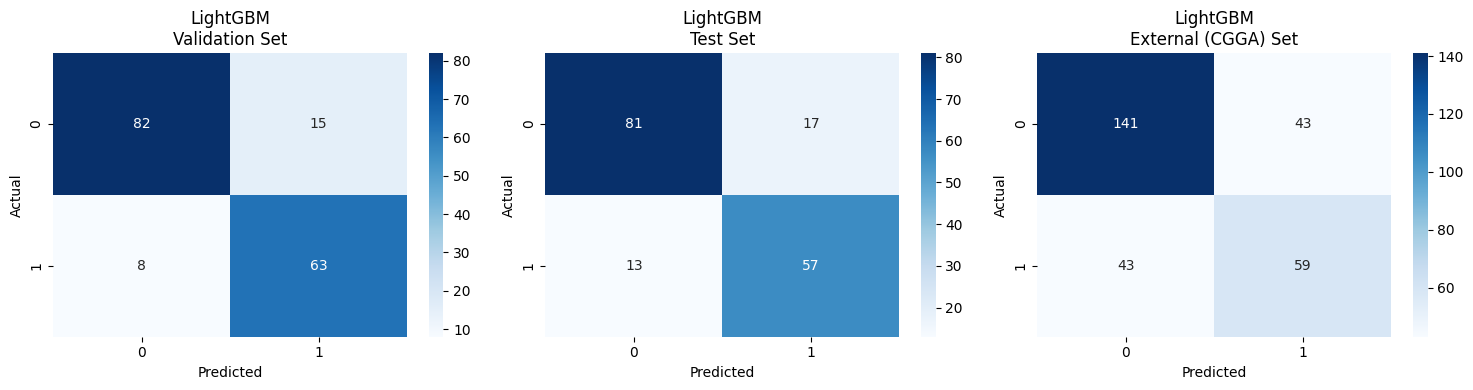

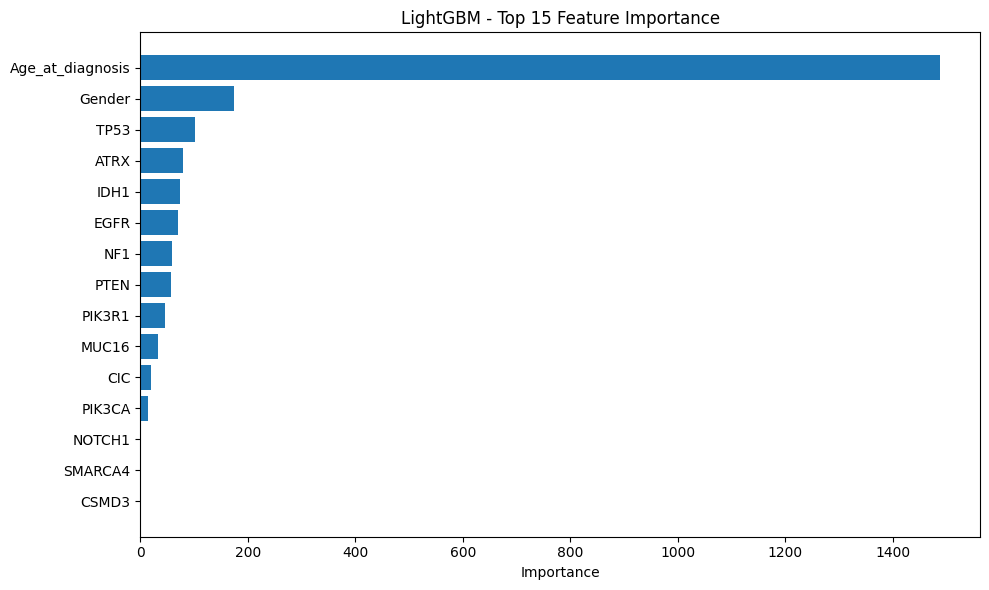

In [42]:
print("\n" + "="*60)
print("7. LIGHTGBM CLASSIFIER")
print("="*60)

lgb_trainer = trainers['LightGBM']

# Cross-validation
lgb_cv_results = lgb_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
lgb_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
lgb_eval_results = lgb_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
lgb_trainer.plot_confusion_matrices()

# Feature importance
lgb_importance = lgb_trainer.get_feature_importance(feature_names)


8. RIDGE CLASSIFIER

Training RidgeClassifier with 10-fold CV
  Fold 1: Accuracy = 0.8814, F1 = 0.8803
  Fold 2: Accuracy = 0.8983, F1 = 0.8981
  Fold 3: Accuracy = 0.8136, F1 = 0.8132
  Fold 4: Accuracy = 0.9153, F1 = 0.9153
  Fold 5: Accuracy = 0.9138, F1 = 0.9138
  Fold 6: Accuracy = 0.8276, F1 = 0.8276
  Fold 7: Accuracy = 0.8448, F1 = 0.8425
  Fold 8: Accuracy = 0.9138, F1 = 0.9138
  Fold 9: Accuracy = 0.8276, F1 = 0.8274
  Fold 10: Accuracy = 0.8966, F1 = 0.8961

CV Averages: Accuracy = 0.8733, Precision = 0.8781, Recall = 0.8733, F1 = 0.8728

Training final RidgeClassifier model...
Training completed!

Evaluating RidgeClassifier...

  Validation Set:
    Accuracy:  0.8690
    Precision: 0.8795
    Recall:    0.8690
    F1-Score:  0.8698

  Test Set:
    Accuracy:  0.8690
    Precision: 0.8829
    Recall:    0.8690
    F1-Score:  0.8700

  External (CGGA) Set:
    Accuracy:  0.6818
    Precision: 0.7286
    Recall:    0.6818
    F1-Score:  0.6884


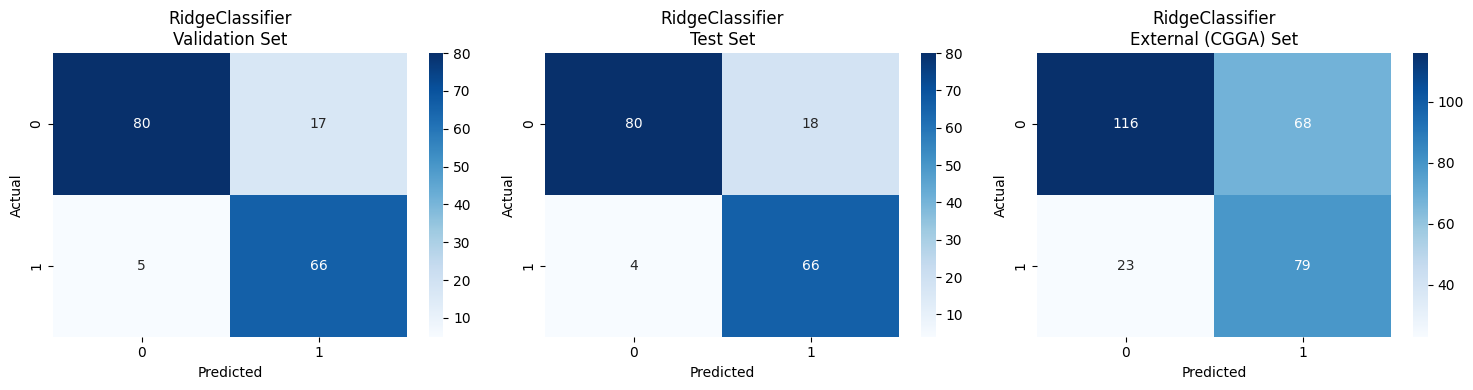

In [43]:
print("\n" + "="*60)
print("8. RIDGE CLASSIFIER")
print("="*60)

ridge_trainer = trainers['RidgeClassifier']

# Cross-validation
ridge_cv_results = ridge_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
ridge_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
ridge_eval_results = ridge_trainer.evaluate(
    X_sets=[X_val_scaled, X_test_scaled, X_cgga_scaled],
    y_sets=[y_val, y_test, y_cgga],
    set_names=['Validation', 'Test', 'External (CGGA)']
)

# Plot confusion matrices
ridge_trainer.plot_confusion_matrices()

In [44]:
print("\n" + "="*80)
print("COMPARISON OF ALL MODELS")
print("="*80)

# Create comparison DataFrame
comparison_data = []

for model_name, trainer in trainers.items():
    if 'evaluation' in trainer.results:
        for dataset, scores in trainer.results['evaluation'].items():
            comparison_data.append({
                'Model': model_name,
                'Dataset': dataset,
                'Accuracy': scores['accuracy'],
                'Precision': scores['precision'],
                'Recall': scores['recall'],
                'F1': scores['f1'],
                'ROC_AUC': scores['roc_auc'] if scores['roc_auc'] else np.nan,
                'CV_F1_Avg': trainer.results['cv_avg']['f1'] if 'cv_avg' in trainer.results else np.nan
            })

comparison_df = pd.DataFrame(comparison_data)
print("\nPerformance Comparison:")
print("-" * 100)
for dataset in ['Validation', 'Test', 'External (CGGA)']:
    print(f"\n{dataset} Set Performance:")
    dataset_df = comparison_df[comparison_df['Dataset'] == dataset]
    print(dataset_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']]
          .sort_values('F1', ascending=False).to_string(index=False))
    print("-" * 100)


COMPARISON OF ALL MODELS

Performance Comparison:
----------------------------------------------------------------------------------------------------

Validation Set Performance:
             Model  Accuracy  Precision   Recall       F1  ROC_AUC
          CatBoost  0.892857   0.900408 0.892857 0.893470 0.933425
LogisticRegression  0.886905   0.895837 0.886905 0.887571 0.922753
          AdaBoost  0.875000   0.886976 0.875000 0.875753 0.933570
   RidgeClassifier  0.869048   0.879476 0.869048 0.869833      NaN
          LightGBM  0.863095   0.867404 0.863095 0.863749 0.908886
      RandomForest  0.857143   0.864846 0.857143 0.857960 0.901554
           XGBoost  0.851190   0.853830 0.851190 0.851753 0.900102
        ExtraTrees  0.827381   0.830156 0.827381 0.828033 0.873748
----------------------------------------------------------------------------------------------------

Test Set Performance:
             Model  Accuracy  Precision   Recall       F1  ROC_AUC
LogisticRegression  0.875


VISUALIZATION OF RESULTS


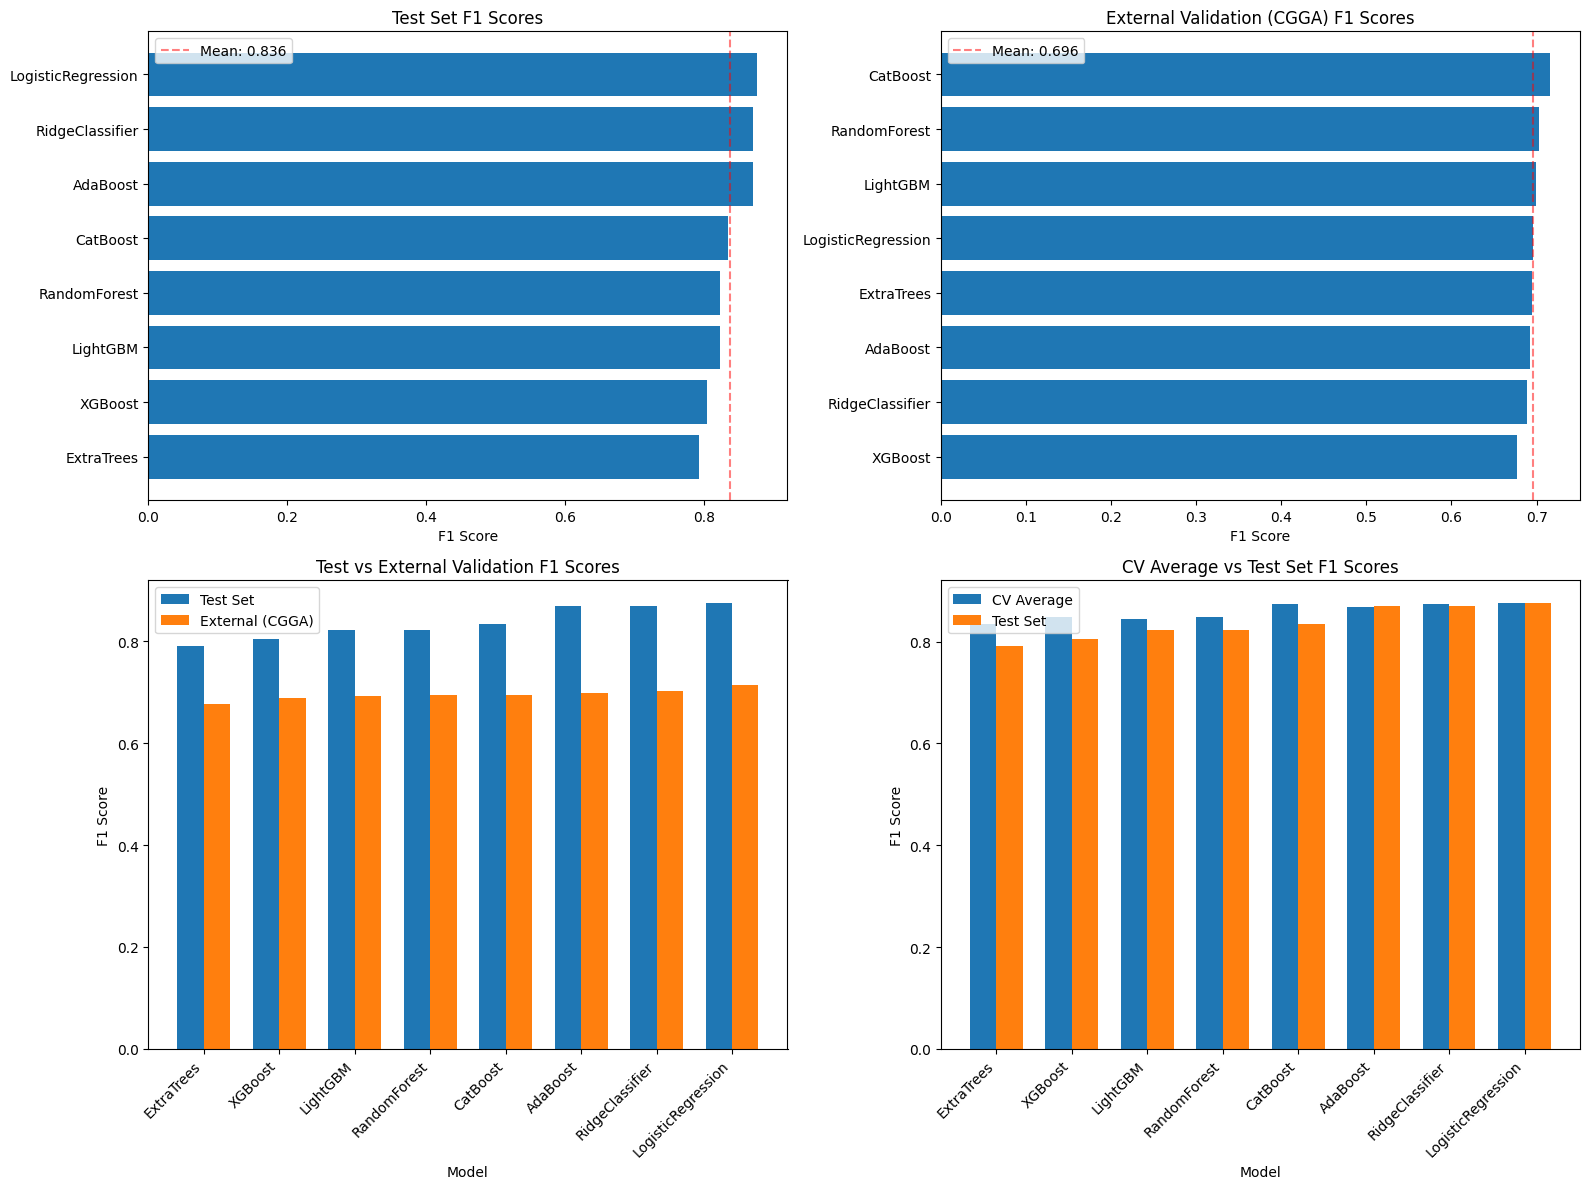

In [45]:
print("\n" + "="*80)
print("VISUALIZATION OF RESULTS")
print("="*80)

# 1. Model comparison by F1 score
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test set F1 scores
test_f1 = comparison_df[comparison_df['Dataset'] == 'Test'].set_index('Model')['F1'].sort_values()
axes[0, 0].barh(test_f1.index, test_f1.values)
axes[0, 0].set_title('Test Set F1 Scores')
axes[0, 0].set_xlabel('F1 Score')
axes[0, 0].axvline(x=test_f1.mean(), color='r', linestyle='--', alpha=0.5, label=f'Mean: {test_f1.mean():.3f}')
axes[0, 0].legend()

# External validation F1 scores
ext_f1 = comparison_df[comparison_df['Dataset'] == 'External (CGGA)'].set_index('Model')['F1'].sort_values()
axes[0, 1].barh(ext_f1.index, ext_f1.values)
axes[0, 1].set_title('External Validation (CGGA) F1 Scores')
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].axvline(x=ext_f1.mean(), color='r', linestyle='--', alpha=0.5, label=f'Mean: {ext_f1.mean():.3f}')
axes[0, 1].legend()

# Test vs External F1 comparison
models = test_f1.index
x = np.arange(len(models))
width = 0.35
axes[1, 0].bar(x - width/2, test_f1.values, width, label='Test Set')
axes[1, 0].bar(x + width/2, ext_f1.values, width, label='External (CGGA)')
axes[1, 0].set_title('Test vs External Validation F1 Scores')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].legend()

# CV vs Test F1 comparison
cv_vs_test = []
for model in models:
    cv_score = comparison_df[(comparison_df['Model'] == model) & 
                            (comparison_df['Dataset'] == 'Test')]['CV_F1_Avg'].values[0]
    test_score = comparison_df[(comparison_df['Model'] == model) & 
                              (comparison_df['Dataset'] == 'Test')]['F1'].values[0]
    cv_vs_test.append((cv_score, test_score))

cv_scores = [x[0] for x in cv_vs_test]
test_scores = [x[1] for x in cv_vs_test]

axes[1, 1].bar(x - width/2, cv_scores, width, label='CV Average')
axes[1, 1].bar(x + width/2, test_scores, width, label='Test Set')
axes[1, 1].set_title('CV Average vs Test Set F1 Scores')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Performance Heatmap (Normalized):


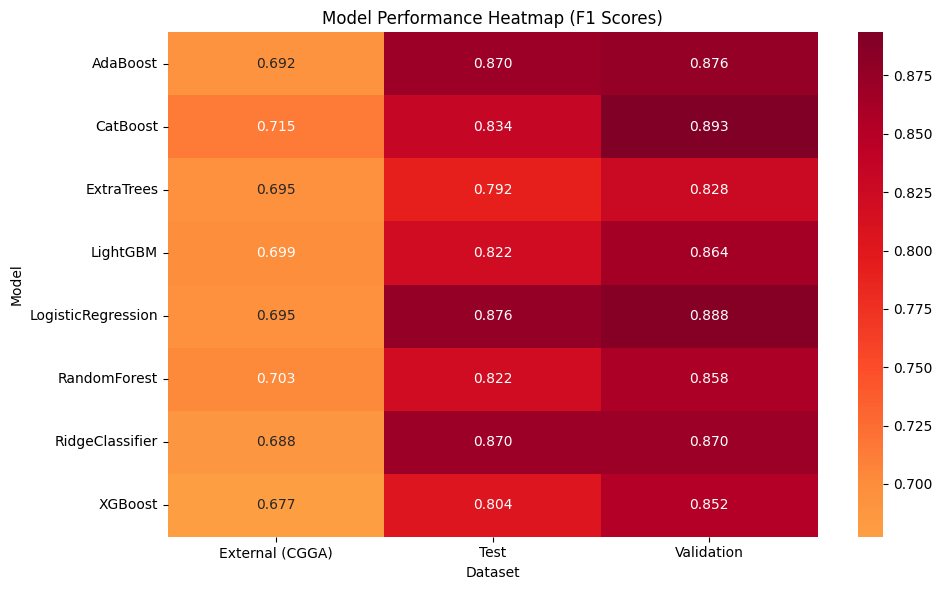

In [46]:
# 2. Performance summary heatmap
print("\nPerformance Heatmap (Normalized):")
# Create a normalized performance matrix
performance_matrix = pd.pivot_table(comparison_df, 
                                   values='F1', 
                                   index='Model', 
                                   columns='Dataset')

plt.figure(figsize=(10, 6))
sns.heatmap(performance_matrix, annot=True, fmt='.3f', cmap='YlOrRd', center=0.7)
plt.title('Model Performance Heatmap (F1 Scores)')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("BEST MODELS ANALYSIS")
print("="*80)

# Find best model for each dataset
datasets = ['Validation', 'Test', 'External (CGGA)']
best_models = {}

for dataset in datasets:
    dataset_df = comparison_df[comparison_df['Dataset'] == dataset]
    best_model = dataset_df.loc[dataset_df['F1'].idxmax()]
    best_models[dataset] = best_model
    print(f"\nBest model for {dataset}:")
    print(f"  Model: {best_model['Model']}")
    print(f"  F1 Score: {best_model['F1']:.4f}")
    print(f"  Accuracy: {best_model['Accuracy']:.4f}")
    print(f"  CV F1 Average: {best_model['CV_F1_Avg']:.4f}")

# Find most consistent model (best average across all datasets)
model_avg_f1 = comparison_df.groupby('Model')['F1'].mean().sort_values(ascending=False)
print(f"\n\nMost consistent model (average F1 across all datasets):")
print(f"  Model: {model_avg_f1.index[0]}")
print(f"  Average F1: {model_avg_f1.values[0]:.4f}")

# Check for overfitting
print("\n\nOverfitting Analysis:")
print("-" * 60)
for model in comparison_df['Model'].unique():
    cv_f1 = comparison_df[(comparison_df['Model'] == model) & 
                         (comparison_df['Dataset'] == 'Test')]['CV_F1_Avg'].values[0]
    test_f1 = comparison_df[(comparison_df['Model'] == model) & 
                           (comparison_df['Dataset'] == 'Test')]['F1'].values[0]
    
    diff = cv_f1 - test_f1
    if diff > 0.15:
        status = "HIGH OVERFITTING"
    elif diff > 0.05:
        status = "Moderate overfitting"
    elif diff < -0.05:
        status = "Underfitting"
    else:
        status = "✓ Good generalization"
    
    print(f"{model:20} CV F1: {cv_f1:.4f}, Test F1: {test_f1:.4f}, Diff: {diff:.4f} - {status}")


BEST MODELS ANALYSIS

Best model for Validation:
  Model: CatBoost
  F1 Score: 0.8935
  Accuracy: 0.8929
  CV F1 Average: 0.8728

Best model for Test:
  Model: LogisticRegression
  F1 Score: 0.8759
  Accuracy: 0.8750
  CV F1 Average: 0.8762

Best model for External (CGGA):
  Model: CatBoost
  F1 Score: 0.7153
  Accuracy: 0.7098
  CV F1 Average: 0.8728


Most consistent model (average F1 across all datasets):
  Model: LogisticRegression
  Average F1: 0.8196


Overfitting Analysis:
------------------------------------------------------------
RandomForest         CV F1: 0.8472, Test F1: 0.8220, Diff: 0.0251 - ✓ Good generalization
LogisticRegression   CV F1: 0.8762, Test F1: 0.8759, Diff: 0.0003 - ✓ Good generalization
XGBoost              CV F1: 0.8489, Test F1: 0.8044, Diff: 0.0445 - ✓ Good generalization
AdaBoost             CV F1: 0.8675, Test F1: 0.8700, Diff: -0.0025 - ✓ Good generalization
ExtraTrees           CV F1: 0.8353, Test F1: 0.7919, Diff: 0.0435 - ✓ Good generalization
Ca

In [48]:
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save comparison DataFrame
comparison_df.to_csv('all_models_comparison.csv', index=False)
print("Comparison results saved to 'all_models_comparison.csv'")

# Save detailed results for each model
for model_name, trainer in trainers.items():
    if trainer.results:
        model_results = pd.DataFrame({
            'Metric': ['CV_Avg_Accuracy', 'CV_Avg_Precision', 'CV_Avg_Recall', 'CV_Avg_F1'] + 
                      [f'{ds}_Accuracy' for ds in ['Validation', 'Test', 'External']] +
                      [f'{ds}_F1' for ds in ['Validation', 'Test', 'External']],
            'Value': [trainer.results['cv_avg']['accuracy'],
                     trainer.results['cv_avg']['precision'],
                     trainer.results['cv_avg']['recall'],
                     trainer.results['cv_avg']['f1'],
                     trainer.results['evaluation']['Validation']['accuracy'],
                     trainer.results['evaluation']['Test']['accuracy'],
                     trainer.results['evaluation']['External (CGGA)']['accuracy'],
                     trainer.results['evaluation']['Validation']['f1'],
                     trainer.results['evaluation']['Test']['f1'],
                     trainer.results['evaluation']['External (CGGA)']['f1']]
        })
        model_results.to_csv(f'{model_name}_results.csv', index=False)

print("Detailed model results saved as CSV files.")


SAVING RESULTS
Comparison results saved to 'all_models_comparison.csv'
Detailed model results saved as CSV files.
